In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

# Features to be added
* img-area
* txt-img ratio
* txt-area feature
* txt-img orientation
* txt-img aspect ratio
* img orientation
* img aspect ratio

# Google Cloud Vision OCR API

In [4]:
import os

MARKER_PATH = "installed_marker.txt"

if os.path.exists(MARKER_PATH):
    print("Running initial setup (pip + google-cloud-vision upgrade)...")
    
    !pip install --upgrade pip
    !pip install -q --upgrade google-cloud-vision
    !pip install --upgrade opencv-python --break-system-packages
    !pip install pandas==2.2.2
    !pip install "numpy<2.0" --force-reinstall

    with open(MARKER_PATH, "w") as f:
        f.write("installed")

    print("Installation complete. Please restart the kernel manually or it will be auto-exited.")
    os._exit(0)
else:
    print("Packages already installed. Skipping setup.")

Packages already installed. Skipping setup.


In [5]:
from google.cloud import vision
import io
import os

# Replace with your actual path to the JSON key file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "cloud-vision-key.json"

In [6]:
from google.cloud import vision
from PIL import Image
import io
import matplotlib.pyplot as plt

# Initialize the Vision client
client = vision.ImageAnnotatorClient()

## negative_022.jpg

Detected text:

obc NEWS SPECIAL REPORT
TWO BOMB EXPLOSIONS AT
THE BOSTON MARATHON
adidas
locale: "en"
description: "obc NEWS SPECIAL REPORT\nTWO BOMB EXPLOSIONS AT\nTHE BOSTON MARATHON\nadidas"
bounding_poly {
  vertices {
    x: 56
    y: 448
  }
  vertices {
    x: 703
    y: 448
  }
  vertices {
    x: 703
    y: 598
  }
  vertices {
    x: 56
    y: 598
  }
}



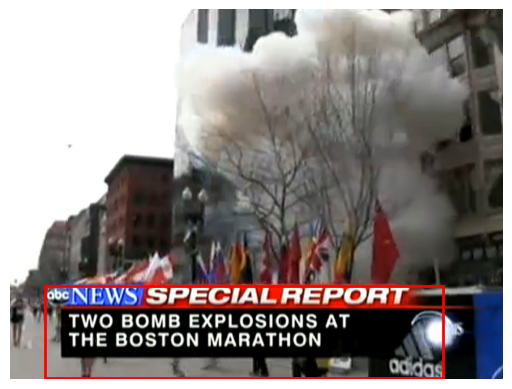

In [7]:
import matplotlib.patches as patches

root = "./../../../dataset/docimsentv1/"

# Load your image
image_path = root+"negative_022.jpg"
with io.open(image_path, 'rb') as image_file:
    content = image_file.read()

image = vision.Image(content=content)

# Perform OCR (Text Detection)
response = client.text_detection(image=image)
texts = response.text_annotations

# Display results
if texts:
    print("Detected text:\n")
    print(texts[0].description)
else:
    print("No text detected.")

print(texts[0])

# Optional: Show image
# img = Image.open(image_path)
# plt.imshow(img)
# plt.axis('off')
# plt.show()

# Display image
img = Image.open(image_path)
fig, ax = plt.subplots()
ax.imshow(img)

# Draw bounding box for the first text block
if texts:
    vertices = [(v.x, v.y) for v in texts[0].bounding_poly.vertices]
    # Create a rectangle
    rect = patches.Polygon(vertices, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

plt.axis('off')
plt.show()

In [8]:
response

text_annotations {
  locale: "en"
  description: "obc NEWS SPECIAL REPORT\nTWO BOMB EXPLOSIONS AT\nTHE BOSTON MARATHON\nadidas"
  bounding_poly {
    vertices {
      x: 56
      y: 448
    }
    vertices {
      x: 703
      y: 448
    }
    vertices {
      x: 703
      y: 598
    }
    vertices {
      x: 56
      y: 598
    }
  }
}
text_annotations {
  description: "obc"
  bounding_poly {
    vertices {
      x: 56
      y: 448
    }
    vertices {
      x: 99
      y: 448
    }
    vertices {
      x: 99
      y: 479
    }
    vertices {
      x: 56
      y: 479
    }
  }
}
text_annotations {
  description: "NEWS"
  bounding_poly {
    vertices {
      x: 99
      y: 448
    }
    vertices {
      x: 208
      y: 448
    }
    vertices {
      x: 208
      y: 479
    }
    vertices {
      x: 99
      y: 479
    }
  }
}
text_annotations {
  description: "SPECIAL"
  bounding_poly {
    vertices {
      x: 221
      y: 448
    }
    vertices {
      x: 435
      y: 448
    }
    ver

In [9]:
texts

[locale: "en"
description: "obc NEWS SPECIAL REPORT\nTWO BOMB EXPLOSIONS AT\nTHE BOSTON MARATHON\nadidas"
bounding_poly {
  vertices {
    x: 56
    y: 448
  }
  vertices {
    x: 703
    y: 448
  }
  vertices {
    x: 703
    y: 598
  }
  vertices {
    x: 56
    y: 598
  }
}
, description: "obc"
bounding_poly {
  vertices {
    x: 56
    y: 448
  }
  vertices {
    x: 99
    y: 448
  }
  vertices {
    x: 99
    y: 479
  }
  vertices {
    x: 56
    y: 479
  }
}
, description: "NEWS"
bounding_poly {
  vertices {
    x: 99
    y: 448
  }
  vertices {
    x: 208
    y: 448
  }
  vertices {
    x: 208
    y: 479
  }
  vertices {
    x: 99
    y: 479
  }
}
, description: "SPECIAL"
bounding_poly {
  vertices {
    x: 221
    y: 448
  }
  vertices {
    x: 435
    y: 448
  }
  vertices {
    x: 435
    y: 479
  }
  vertices {
    x: 221
    y: 479
  }
}
, description: "REPORT"
bounding_poly {
  vertices {
    x: 440
    y: 448
  }
  vertices {
    x: 646
    y: 448
  }
  vertices {
    x: 

## negative_006.jpg

Detected text:

R. TURKEY TO HOST TALKS?
WORLD
AT WAR
R. BREAKING
NEWS
ZELENSKYY:
NATO ALLOWING
BOMBINGS IN
UKR
DAY 10 OF RUSSIAN OFFENSIVE
RUSSIA CLAIMS UKRAINE PRESIDENT FLED TO POLAND
locale: "en"
description: "R. TURKEY TO HOST TALKS?\nWORLD\nAT WAR\nR. BREAKING\nNEWS\nZELENSKYY:\nNATO ALLOWING\nBOMBINGS IN\nUKR\nDAY 10 OF RUSSIAN OFFENSIVE\nRUSSIA CLAIMS UKRAINE PRESIDENT FLED TO POLAND"
bounding_poly {
  vertices {
    x: 62
    y: 28
  }
  vertices {
    x: 641
    y: 28
  }
  vertices {
    x: 641
    y: 326
  }
  vertices {
    x: 62
    y: 326
  }
}



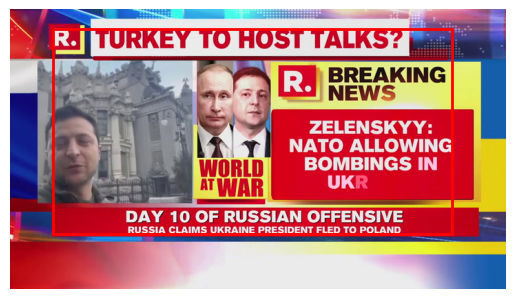

In [10]:
import matplotlib.patches as patches

root = "./../../../dataset/docimsentv1/"

# Load your image
image_path = root+"negative_006.jpg"
with io.open(image_path, 'rb') as image_file:
    content = image_file.read()

image = vision.Image(content=content)

# Perform OCR (Text Detection)
response = client.text_detection(image=image)
texts = response.text_annotations

# Display results
if texts:
    print("Detected text:\n")
    print(texts[0].description)
else:
    print("No text detected.")

print(texts[0])

# Optional: Show image
# img = Image.open(image_path)
# plt.imshow(img)
# plt.axis('off')
# plt.show()

# Display image
img = Image.open(image_path)
fig, ax = plt.subplots()
ax.imshow(img)

# Draw bounding box for the first text block
if texts:
    vertices = [(v.x, v.y) for v in texts[0].bounding_poly.vertices]
    # Create a rectangle
    rect = patches.Polygon(vertices, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

plt.axis('off')
plt.show()

## negative_005.jpg

Detected text:

HUNDREDS
KILLED IN
UKRAINE
>NEWS
NIGHTLY AT 6
locale: "en"
description: "HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6"
bounding_poly {
  vertices {
    x: 20
    y: 61
  }
  vertices {
    x: 508
    y: 61
  }
  vertices {
    x: 508
    y: 704
  }
  vertices {
    x: 20
    y: 704
  }
}



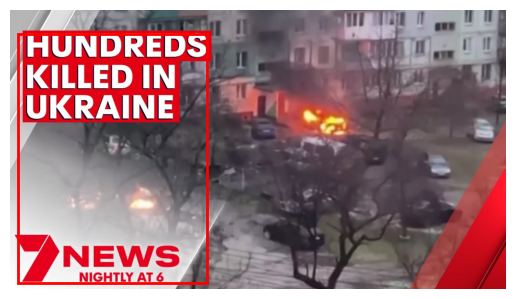

In [11]:
import matplotlib.patches as patches

root = "./../../../dataset/docimsentv1/"

# Load your image
image_path = root+"negative_005.jpg"
with io.open(image_path, 'rb') as image_file:
    content = image_file.read()

image = vision.Image(content=content)

# Perform OCR (Text Detection)
response = client.text_detection(image=image)
texts = response.text_annotations

# Display results
if texts:
    print("Detected text:\n")
    print(texts[0].description)
else:
    print("No text detected.")

print(texts[0])

# Optional: Show image
# img = Image.open(image_path)
# plt.imshow(img)
# plt.axis('off')
# plt.show()

# Display image
img = Image.open(image_path)
fig, ax = plt.subplots()
ax.imshow(img)

# Draw bounding box for the first text block
if texts:
    vertices = [(v.x, v.y) for v in texts[0].bounding_poly.vertices]
    # Create a rectangle
    rect = patches.Polygon(vertices, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

plt.axis('off')
plt.show()

## negative_001.jpg

Detected text:

STOP WAR
UKRAINE
IN
Слава Україні!
MAKE
NOT
locale: "en"
description: "STOP WAR\nUKRAINE\nIN\n\320\241\320\273\320\260\320\262\320\260 \320\243\320\272\321\200\320\260\321\227\320\275\321\226!\nMAKE\nNOT"
bounding_poly {
  vertices {
    x: 513
    y: 24
  }
  vertices {
    x: 975
    y: 24
  }
  vertices {
    x: 975
    y: 263
  }
  vertices {
    x: 513
    y: 263
  }
}



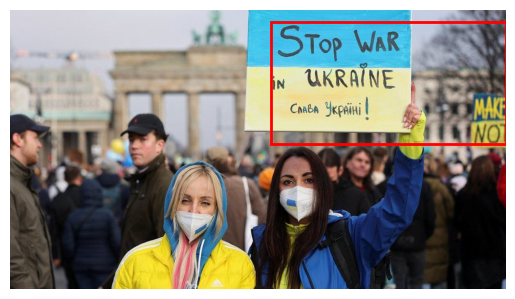

In [12]:
import matplotlib.patches as patches

root = "./../../../dataset/docimsentv1/"

# Load your image
image_path = root+"negative_001.jpg"
with io.open(image_path, 'rb') as image_file:
    content = image_file.read()

image = vision.Image(content=content)

# Perform OCR (Text Detection)
response = client.text_detection(image=image)
texts = response.text_annotations

# Display results
if texts:
    print("Detected text:\n")
    print(texts[0].description)
else:
    print("No text detected.")

print(texts[0])

# Optional: Show image
# img = Image.open(image_path)
# plt.imshow(img)
# plt.axis('off')
# plt.show()

# Display image
img = Image.open(image_path)
fig, ax = plt.subplots()
ax.imshow(img)

# Draw bounding box for the first text block
if texts:
    vertices = [(v.x, v.y) for v in texts[0].bounding_poly.vertices]
    # Create a rectangle
    rect = patches.Polygon(vertices, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

plt.axis('off')
plt.show()

# All-Info

x = x-axis = width

y = y-axis = height

In [13]:
# Define standard aspect ratios
standard_ratios = {
    "1:1": 1.0, # 1 BOX
    "4:3": 4/3, # 1.33 Horizontal
    "3:2": 3/2, # 1.5 Horizontal
    "16:9": 16/9, # 1.78 Horizontal
    "16:9": 17/9, # 1.93 Horizontal
    "5:4": 5/4, # 1.25 Horizontal
    "21:9": 21/9, # 2.33 Horizontal
    "2:1": 2.0, # 2 Horizontal
    "7:5": 7/5, # 1.4 Horizontal
    # "A4 (1.41:1)": 1.41,
    "3:4": 3/4, # 0.75 Vertical
    "2:3": 2/3, # 0.67 Vertical
    "9:16": 9/16, # 0.5625 Vertical
    "5:7": 5/7, # 0.71 Vertical
    "4:5": 4/5, # 0.8 Vertical
    "A-series (1:√2)": 1/1.414, # 0.707 Vertical
    "2:5": 2/5, # 0.4 Vertical
    "1:3":1/3, # 0.33 Vertical
    "Other":0
}

# Function to match image to closest standard aspect ratio
def closest_standard_ratio(width, height, tolerance=0.15):
    if height == 0:
        return "Invalid"
    ratio = width / height
    # print(ratio)
    for name, std_ratio in standard_ratios.items():
        # print("std_ratio =",std_ratio, "; difference:",abs(ratio - std_ratio))
        # print()
        if abs(ratio - std_ratio) <= tolerance:
            # print(ratio, std_ratio)
            return name
    return "Other"


In [14]:
aspect_ratio_orientation = {
    # --- Box-like (almost square) ---
    "1:1": "box",

    # --- Horizontal (landscape) ---
    "4:3": "horizontal",      # 1.33
    "3:2": "horizontal",      # 1.5
    "16:9": "horizontal",     # 1.78
    "5:4": "horizontal",      # 1.25
    "21:9": "horizontal",     # 2.33
    "2:1": "horizontal",      # 2.0
    "7:5": "horizontal",      # 1.4
    "A4 (1.41:1)": "horizontal",  # 1.41

    # --- Vertical (portrait) ---
    "3:4": "vertical",        # 0.75
    "2:3": "vertical",        # 0.666
    "9:16": "vertical",       # 0.5625
    "5:7": "vertical",        # 0.714
    "4:5": "vertical",        # 0.8
    "A-series (1:√2)": "vertical",  # ≈0.707
    "2:5": "vertical",        # 0.4

    # --- Catch-all ---
    # "Other": "other"
    "Other": "other"
}



# Helper function to classify orientation
def get_orientation(aspect_ratio="Other"):
    return aspect_ratio_orientation[aspect_ratio]






In [15]:
import os
from PIL import Image
from collections import defaultdict
import pandas as pd

# gcv-ocr.csv was constructed to extract the OCR using the Google Cloud Vision API

root = "/kaggle/input/musait/gcv-ocr.csv"
df = pd.read_csv(root)

df

,filename,filepath,text-detected,OCR,coordinates,sentiment
0,negative_001.jpg,/kaggle/input/musait/basket/negative_001.jpg,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",negative
1,negative_002.jpg,/kaggle/input/musait/basket/negative_002.jpg,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",negative
2,negative_003.jpg,/kaggle/input/musait/basket/negative_003.jpg,0,NaN,[],negative
3,negative_004.jpg,/kaggle/input/musait/basket/negative_004.jpg,0,NaN,[],negative
4,negative_005.jpg,/kaggle/input/musait/basket/negative_005.jpg,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",negative
...,...,...,...,...,...,...
2870,positive_995.jpg,/kaggle/input/musait/basket/positive_995.jpg,1,"66\nJust keep taking\nchances and\nhaving fun,...","[{'x': 129, 'y': 157}, {'x': 587, 'y': 157}, {...",positive
2871,positive_996.jpg,/kaggle/input/musait/basket/positive_996.jpg,1,66\nNever regret anything\nthat made you smile...,"[{'x': 15, 'y': 144}, {'x': 710, 'y': 144}, {'...",positive
2872,positive_997.jpg,/kaggle/input/musait/basket/positive_997.jpg,1,"Click Here\nif you don't\nimagine, nothing\nev...","[{'x': 29, 'y': 32}, {'x': 608, 'y': 32}, {'x'...",positive
2873,positive_998.jpg,/kaggle/input/musait/basket/positive_998.jpg,1,OF COURSE IT'S HARD.\nIT'S SUPPOSED TO BE\nHAR...,"[{'x': 78, 'y': 296}, {'x': 660, 'y': 296}, {'...",positive


In [16]:
type(df['OCR'][2])

float

In [17]:
# Features to be added
# * img-area
# * txt-img ratio
# * txt-area feature
# * txt-img orientation
# * txt-img aspect ratio
# * img orientation
# * img aspect ratio

## New features

In [18]:
txt_area = []
txt_ar, txt_or= [],[]

txt_img_ratio = []

img_ar, img_or = [],[]
img_area = []


# txt_area_columnNames = list(standard_ratios.keys())
# txt_area_rowNames = ["positive", "negative", "neutral"]

# txt_area_ar_df = pd.DataFrame(0, index=txt_area_rowNames, columns=txt_area_columnNames)



# columnNames = ["vertical", "horizontal","box"]
# rowNames = ["positive", "negative", "neutral"]

# Create a DataFrame filled with zeros
# txt_area_orientation_df = pd.DataFrame(0, index=rowNames, columns=columnNames)

In [19]:
df['coordinates'][0]

"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x': 975, 'y': 263}, {'x': 513, 'y': 263}]"

In [20]:
import ast  # Safe way to evaluate the string into a list

# Step 1: Parse the string to a Python list
s = "[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x': 975, 'y': 263}, {'x': 513, 'y': 263}]"
points = ast.literal_eval(s)

# Step 2: Extract x and y values separately
x_values = [point['x'] for point in points]
y_values = [point['y'] for point in points]

# Step 3: Calculate width and height
width = max(x_values) - min(x_values)
height = max(y_values) - min(y_values)

print(width, height)

462 239


In [21]:
len(df)

2875

In [22]:
from PIL import Image
from IPython.display import display
from tqdm.notebook import tqdm

count = 0
length = len(df)

for i in tqdm(range(length)):
    fname = df['filename'][i]

    # -------------------------- image --------------------------------
    image = Image.open("/kaggle/input/musait/dataset/basket/"+fname)
    img_width, img_height = image.size
    # print(fname)
    # display(image)
    # print(f"Image width = {img_width}; Image height = {img_height}")

    img_area+=[img_height*img_width]

    ar_img = closest_standard_ratio(img_width, img_height)
    orientation_img = aspect_ratio_orientation[ar_img]
    img_ar+=[ar_img]
    img_or+=[orientation_img]

    # print("img_ar:", img_ar)
    # print("img_or:", img_or)
    # print("img_area:", img_area)
    # print("--------------------------------")

    
    
    # -------------------------- text --------------------------------
    sentiment = df['sentiment'][i]
    s = df['coordinates'][i]
    
    # print(s,"Ekhane", type(s))
    # print(points)
    if s=="[]":
        txt_ar+=[float('nan')]
        txt_or+=[float('nan')]
        txt_area+=[0]
        txt_img_ratio+=[0]
        # print("Hi")
        # continue
        # break
    else:
        points = ast.literal_eval(s)
        
        x_values = [point['x'] for point in points]
        y_values = [point['y'] for point in points]
        # print(x_values)
        # print(y_values)
        # break
        txt_width = max(x_values) - min(x_values)
        txt_height = max(y_values) - min(y_values)
        # print(f"txt width = {txt_width}; txt height = {txt_height}")
    
        txt_area+=[txt_width*txt_height]
        
        ar_txt = closest_standard_ratio(txt_width, txt_height)
        orientation_txt = aspect_ratio_orientation[ar_txt]
        txt_ar+=[ar_txt]
        txt_or+=[orientation_txt]
        txt_img_ratio+= [txt_area[i]/img_area[i]]
    
    # txt_area_ar_df.loc[sentiment,ar]+=1
    # txt_area_orientation_df.loc[sentiment,orientation]+=1
    # print("txt_area:", txt_area)
    # print("txt_ar:", txt_ar)
    # print("txt_or:", txt_or)
    # print()
    # print("txt_img_ratio:", txt_img_ratio)
    # break




print("DONE!")

  0%|          | 0/2875 [00:00<?, ?it/s]

DONE!


In [23]:
print(f"txt_img_ratio = {len(txt_img_ratio)}")
print(f"txt_area = {len(txt_area)}")
print(f"txt_ar = {len(txt_ar)}")
print(f"txt_or = {len(txt_or)}")
print(f"img_area = {len(img_area)}")
print(f"img_or = {len(img_or)}")
print(f"img_ar = {len(img_ar)}")

txt_img_ratio = 2875
txt_area = 2875
txt_ar = 2875
txt_or = 2875
img_area = 2875
img_or = 2875
img_ar = 2875


In [24]:
# txt_area = []
# txt_ar, txt_or= [],[]

# txt_img_ratio = []

# img_ar, img_or = [],[]
# img_area = []


new_info = pd.DataFrame(
    {
        "img_ar": img_ar,
        "img_or": img_or,
        "img_area":img_area,
        "txt_ar": txt_ar,
        "txt_or": txt_or,
        "txt_area":txt_area,
        "txt_img_ratio": txt_img_ratio
    }
)

In [25]:
new_info

,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio
0,16:9,horizontal,535824,16:9,horizontal,110418,0.206071
1,16:9,horizontal,921600,3:4,vertical,313784,0.340477
2,16:9,horizontal,810000,NaN,NaN,0,0.000000
3,4:3,horizontal,50246,NaN,NaN,0,0.000000
4,16:9,horizontal,921600,3:4,vertical,313784,0.340477
...,...,...,...,...,...,...,...
2870,1:1,box,540225,4:3,horizontal,141522,0.261969
2871,1:1,box,540225,Other,other,172360,0.319052
2872,3:4,vertical,843045,2:3,vertical,633426,0.751355
2873,3:4,vertical,810705,3:4,vertical,439410,0.542010


In [26]:
new_df = pd.concat([df.iloc[:, :-1], new_info, df.iloc[:, -1]], axis=1)
new_df

,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,sentiment
0,negative_001.jpg,/kaggle/input/musait/basket/negative_001.jpg,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",16:9,horizontal,535824,16:9,horizontal,110418,0.206071,negative
1,negative_002.jpg,/kaggle/input/musait/basket/negative_002.jpg,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,negative
2,negative_003.jpg,/kaggle/input/musait/basket/negative_003.jpg,0,NaN,[],16:9,horizontal,810000,NaN,NaN,0,0.000000,negative
3,negative_004.jpg,/kaggle/input/musait/basket/negative_004.jpg,0,NaN,[],4:3,horizontal,50246,NaN,NaN,0,0.000000,negative
4,negative_005.jpg,/kaggle/input/musait/basket/negative_005.jpg,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2870,positive_995.jpg,/kaggle/input/musait/basket/positive_995.jpg,1,"66\nJust keep taking\nchances and\nhaving fun,...","[{'x': 129, 'y': 157}, {'x': 587, 'y': 157}, {...",1:1,box,540225,4:3,horizontal,141522,0.261969,positive
2871,positive_996.jpg,/kaggle/input/musait/basket/positive_996.jpg,1,66\nNever regret anything\nthat made you smile...,"[{'x': 15, 'y': 144}, {'x': 710, 'y': 144}, {'...",1:1,box,540225,Other,other,172360,0.319052,positive
2872,positive_997.jpg,/kaggle/input/musait/basket/positive_997.jpg,1,"Click Here\nif you don't\nimagine, nothing\nev...","[{'x': 29, 'y': 32}, {'x': 608, 'y': 32}, {'x'...",3:4,vertical,843045,2:3,vertical,633426,0.751355,positive
2873,positive_998.jpg,/kaggle/input/musait/basket/positive_998.jpg,1,OF COURSE IT'S HARD.\nIT'S SUPPOSED TO BE\nHAR...,"[{'x': 78, 'y': 296}, {'x': 660, 'y': 296}, {'...",3:4,vertical,810705,3:4,vertical,439410,0.542010,positive


In [27]:
new_df.to_csv("all_info.csv",index=False)

# All info (uniques)

In [5]:
df = pd.read_csv("./../../all_info.csv")
uniques = os.listdir("./../../../dataset/docimsentv1")
uniques.sort()

all_info_uniques = df[df["filename"].isin(uniques)]
all_info_uniques

,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,sentiment
0,negative_001.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",16:9,horizontal,535824,16:9,horizontal,110418,0.206071,negative
1,negative_002.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,negative
2,negative_003.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],16:9,horizontal,810000,NaN,NaN,0,0.000000,negative
3,negative_004.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],4:3,horizontal,50246,NaN,NaN,0,0.000000,negative
5,negative_006.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,R. TURKEY TO HOST TALKS?\nWORLD\nAT WAR\nR. BR...,"[{'x': 62, 'y': 28}, {'x': 641, 'y': 28}, {'x'...",16:9,horizontal,292320,16:9,horizontal,172542,0.590250,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2870,positive_995.jpg,/kaggle/input/musait/dataset/basket/positive_9...,1,"66\nJust keep taking\nchances and\nhaving fun,...","[{'x': 129, 'y': 157}, {'x': 587, 'y': 157}, {...",1:1,box,540225,4:3,horizontal,141522,0.261969,positive
2871,positive_996.jpg,/kaggle/input/musait/dataset/basket/positive_9...,1,66\nNever regret anything\nthat made you smile...,"[{'x': 15, 'y': 144}, {'x': 710, 'y': 144}, {'...",1:1,box,540225,Other,other,172360,0.319052,positive
2872,positive_997.jpg,/kaggle/input/musait/dataset/basket/positive_9...,1,"Click Here\nif you don't\nimagine, nothing\nev...","[{'x': 29, 'y': 32}, {'x': 608, 'y': 32}, {'x'...",3:4,vertical,843045,2:3,vertical,633426,0.751355,positive
2873,positive_998.jpg,/kaggle/input/musait/dataset/basket/positive_9...,1,OF COURSE IT'S HARD.\nIT'S SUPPOSED TO BE\nHAR...,"[{'x': 78, 'y': 296}, {'x': 660, 'y': 296}, {'...",3:4,vertical,810705,3:4,vertical,439410,0.542010,positive


In [6]:
all_info_uniques.to_csv("./../../../dataset/docimsent/docimsentv1.csv",index=False)